##1.1: Call API from Kaggle to download dataset

In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_dbe57dc4fdc07c5b765756e711f68b39"
!pip install kaggle
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          21174        454                1  
elvisbui/world-happiness-report-2005-2025-panel                     World Happiness Report 2005-2025 Panel                   47102  2026-04-22 15:46:03.890000            991         32                1  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           2138         54

##1.2: Download dataset from Kaggle to the content folder (temporary file)

In [2]:
!kaggle datasets download -d puneet6060/intel-image-classification -p /content

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


##1.3: Extract the zip file to the data folder

In [3]:
import zipfile

zip_path = "/content/intel-image-classification.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

print("Done extracting")

Done extracting


In [4]:
print(os.listdir("/content/data"))

['seg_pred', 'seg_train', 'seg_test']


In [5]:
train_path = "/content/data/seg_train/seg_train"

print(os.listdir(train_path))

['sea', 'mountain', 'glacier', 'forest', 'buildings', 'street']


##1.4: Set classes in list and assign index to each class

In [6]:
classes = sorted(os.listdir(train_path))

class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

print(classes)
print(class_to_idx)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


##1.5: Make 2 list that contain the image's paths and another one contain the labels

In [7]:
image_paths = []
labels = []

for cls in classes:
    cls_folder = os.path.join(train_path, cls)

    for img_name in os.listdir(cls_folder):
        image_paths.append(os.path.join(cls_folder, img_name))
        labels.append(class_to_idx[cls])

print(len(image_paths), len(labels))

14034 14034


##2: Set the dataset that can fetch the images from the folder

In [8]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):               # get the length of the list that contain the images
        return len(self.image_paths)

    def __getitem__(self, idx):      # get the image and it's label
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label
dataset = CustomDataset(image_paths, labels, train_transform)

##2.1: Set the dataloader that shuffle the images and can train the model with batchs

In [9]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=32, shuffle=True) # the data is distributed in batches in random from every folder

##3: visualize the number of images at each label

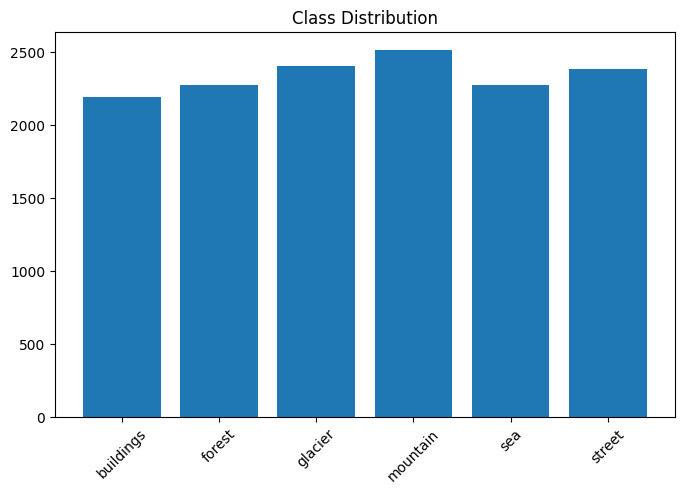

In [10]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(labels) # count the value in labels

classes_names = list(class_to_idx.keys())
values = [counts[c] for c in class_to_idx.values()]  # make list the contain the value's count

plt.figure(figsize=(8,5))
plt.bar(classes_names, values)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

##3.1: visual random images

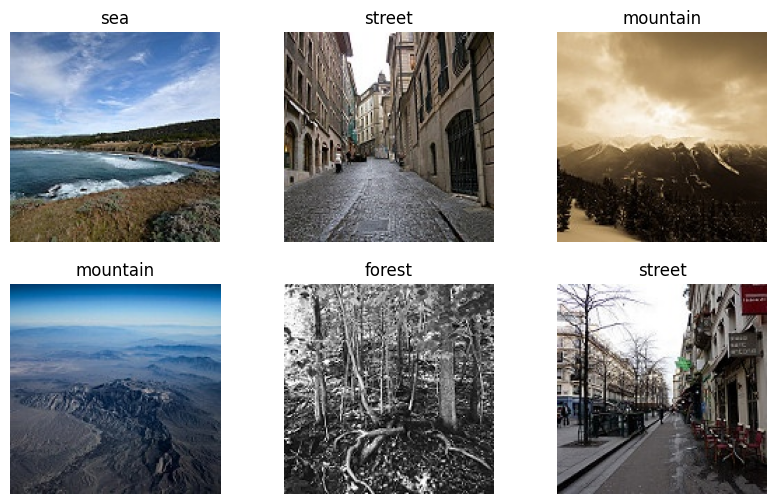

In [11]:
import random
import numpy as np

plt.figure(figsize=(10,6))

for i in range(6):
    idx = random.randint(0, len(image_paths)-1)

    img = Image.open(image_paths[idx])
    label = labels[idx]

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(classes_names[label])
    plt.axis("off")

plt.show()

## 3.2: Set the dataset

In [12]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
val_dataset.dataset = CustomDataset(image_paths, labels, val_transform)
val_dataset.indices = list(range(train_size, len(dataset)))

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [14]:
test_path = '/content/data/seg_test/seg_test'
classes = sorted(os.listdir(test_path))

print(classes)
print(class_to_idx)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [15]:
image_paths_test = []
labels_test = []

for cls in classes:
    cls_folder = os.path.join(test_path, cls)

    for img_name in os.listdir(cls_folder):
        image_paths_test.append(os.path.join(cls_folder, img_name))
        labels_test.append(class_to_idx[cls])

In [16]:
len(image_paths_test), len(labels_test)

(3000, 3000)

In [17]:
test_dataset = CustomDataset(image_paths_test, labels_test, val_transform)

In [18]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False  # important in test dataset beacuse no train here
)

##4: Build the model

In [22]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),# RGB Channel (input layer) = 3, filter num = 32, kernel size = 3, BatchNorm2d(32) -> = filter num
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # input layer = pre(filter num)
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), # = filters *10 *10,   10 = img size after max pooling
            nn.Linear(128 * 16 * 16, 512), nn.ReLU(), nn.Dropout(0.3),  # turn 10*10*128 (from flatten) to 512
            nn.Linear(512, num_classes) # 512 from pre layer
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN(num_classes=len(class_to_idx))

##4.1: Build optimizer

In [23]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

Using device: cuda


##4.2: Train the model using training loop and validation

In [24]:
epochs = 40
patience = 7
best_val_acc = 0
patience_counter = 0
best_model_weights = None

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = total_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===== VALIDATION =====
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_acc)

    print(f"Epoch {epoch+1} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.2f} | "
          f"Val Acc: {val_acc:.2f}")

    # ===== EARLY STOPPING & CHECKPOINT =====
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        best_model_weights = model.state_dict().copy()
        print(f"New best model saved! Val Acc: {best_val_acc:.2f}")
    else:
        patience_counter += 1
        print(f"No improvement {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping! Best Val Acc: {best_val_acc:.2f}")
            break


model.load_state_dict(best_model_weights)
print(f"\nBest model loaded with Val Acc: {best_val_acc:.2f}")

Epoch 1 | Train Loss: 1.9129 | Val Loss: 0.8397 | Train Acc: 42.84 | Val Acc: 71.61
New best model saved! Val Acc: 71.61
Epoch 2 | Train Loss: 1.2014 | Val Loss: 0.6466 | Train Acc: 52.04 | Val Acc: 73.10
New best model saved! Val Acc: 73.10
Epoch 3 | Train Loss: 1.0953 | Val Loss: 0.5458 | Train Acc: 55.86 | Val Acc: 77.24
New best model saved! Val Acc: 77.24
Epoch 4 | Train Loss: 1.0431 | Val Loss: 0.9741 | Train Acc: 58.34 | Val Acc: 58.78
No improvement 1/7
Epoch 5 | Train Loss: 1.0132 | Val Loss: 0.6460 | Train Acc: 59.81 | Val Acc: 75.20
No improvement 2/7
Epoch 6 | Train Loss: 0.9895 | Val Loss: 0.8238 | Train Acc: 60.92 | Val Acc: 69.36
No improvement 3/7
Epoch 7 | Train Loss: 0.9417 | Val Loss: 0.5439 | Train Acc: 63.26 | Val Acc: 79.98
New best model saved! Val Acc: 79.98
Epoch 8 | Train Loss: 0.9240 | Val Loss: 0.4862 | Train Acc: 63.88 | Val Acc: 81.26
New best model saved! Val Acc: 81.26
Epoch 9 | Train Loss: 0.8766 | Val Loss: 0.6836 | Train Acc: 66.54 | Val Acc: 74.71
No

## 6: Evaluate the model

In [25]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Final Test Accuracy:", 100 * correct / total)

Final Test Accuracy: 85.96666666666667


##7: Visualize the result

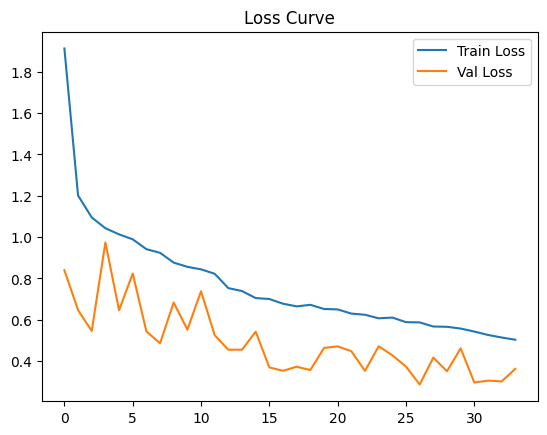

In [26]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

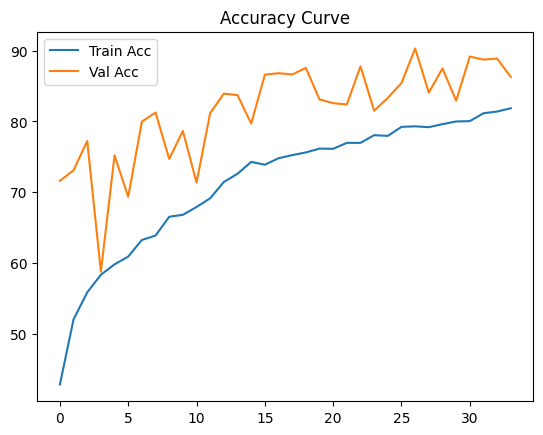

In [27]:
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

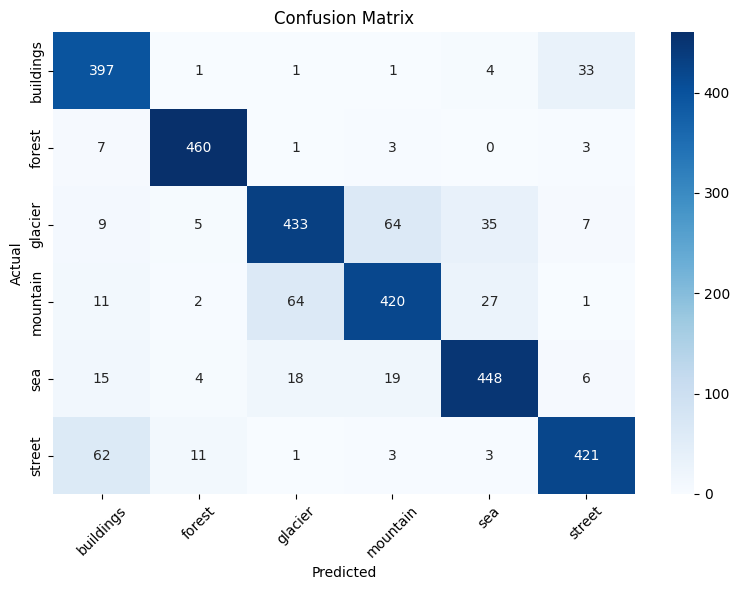

              precision    recall  f1-score   support

   buildings       0.79      0.91      0.85       437
      forest       0.95      0.97      0.96       474
     glacier       0.84      0.78      0.81       553
    mountain       0.82      0.80      0.81       525
         sea       0.87      0.88      0.87       510
      street       0.89      0.84      0.87       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Classification Report
print(classification_report(all_labels, all_preds, target_names=classes))